Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday'],
      dtype='object')
         Store  DayOfWeek       Date  Sales  Customers  Open  Promo  \
0            1          5 2015-07-31   5263        555     1      1   
1115         1          4 2015-07-30   5020        546     1      1   
2230         1          3 2015-07-29   4782        523     1      1   
3345         1          2 2015-07-28   5011        560     1      1   
4460         1          1 2015-07-27   6102        612     1      1   
...        ...        ...        ...    ...        ...   ...    ...   
1011635      1          6 2013-01-05   4997        635     1      0   
1012750      1          5 2013-01-04   4486        619     1      0   
1013865      1          4 2013-01-03   4327        578     1      0   
1014980      1          3 2013-01-02   5530        668     1      0   
1016095      1          2 2013-01-01      0          0     0      0   

        

C:\Users\BC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\BC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)
C:\Users\BC\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-SUN will be used.
  self._init_dates(dates, freq)


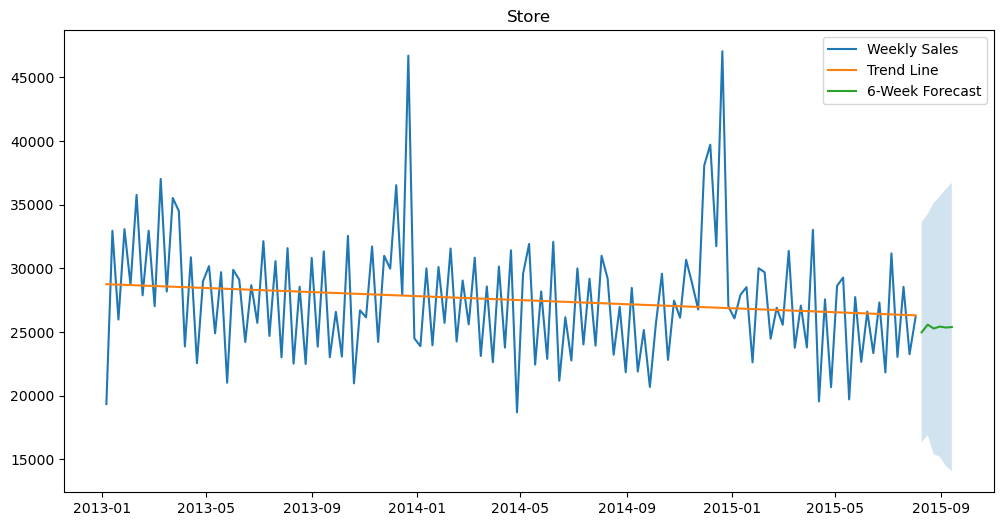

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.api import OLS, add_constant
from statsmodels.tsa.arima.model import ARIMA
df = pd.read_csv("train.csv", parse_dates=["Date"], low_memory=False)
print(df.columns)
store = df[df["Store"] == 1].copy()
print(store)
store_weekly = store.resample("W", on="Date")["Sales"].sum().reset_index()
print(store_weekly)
store_weekly["t"] = range(1, len(store_weekly) + 1)
print(store_weekly["t"])
X = add_constant(store_weekly["t"])
y = store_weekly["Sales"]

trend_model = OLS(y, X).fit()

slope = trend_model.params["t"]
pvalue = trend_model.pvalues["t"]

print("Trend slope =", slope)
print("Trend p-value =", pvalue)
ts = store_weekly.set_index("Date")["Sales"]

arima_model = ARIMA(ts, order=(1,1,1)).fit()
fc = arima_model.get_forecast(steps=6)

f_mean = fc.predicted_mean
f_ci = fc.conf_int()
forecast_table = pd.DataFrame({
    "week": f_mean.index,
    "forecast_sales": f_mean.values,
    "lower_95": f_ci.iloc[:,0].values,
    "upper_95": f_ci.iloc[:,1].values
})

print(forecast_table)
plt.figure(figsize=(12,6))

# Historical weekly sales
plt.plot(store_weekly["Date"], store_weekly["Sales"], label="Weekly Sales")

# Trend line
trend_line = trend_model.predict(X)
plt.plot(store_weekly["Date"], trend_line, label="Trend Line")

# Forecast
plt.plot(f_mean.index, f_mean.values, label="6-Week Forecast")
plt.fill_between(f_mean.index, f_ci.iloc[:,0], f_ci.iloc[:,1], alpha=0.2)

plt.title("Store")
plt.legend()
plt.show()



Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')
Invalid dates: 3870
        Date  Weekly_Sales
0 2010-01-10   42239875.87
1 2010-01-17          0.00
2 2010-01-24          0.00
3 2010-01-31          0.00
4 2010-02-07   99341315.76
            Weekly_Sales
Date                    
2010-01-10   42239875.87
2010-01-17          0.00
2010-01-24          0.00
2010-01-31          0.00
2010-02-07   99341315.76
...                  ...
2012-11-18          0.00
2012-11-25          0.00
2012-12-02          0.00
2012-12-09          0.00
2012-12-16   46128514.25

[154 rows x 1 columns]
Date
2010-01-10    42239875.87
2010-01-17           0.00
2010-01-24           0.00
2010-01-31           0.00
2010-02-07    99341315.76
                 ...     
2012-11-18           0.00
2012-11-25           0.00
2012-12-02           0.00
2012-12-09           0.00
2012-12-16    46128514.25
Name: Weekly_Sales, Length: 154, dtype: 

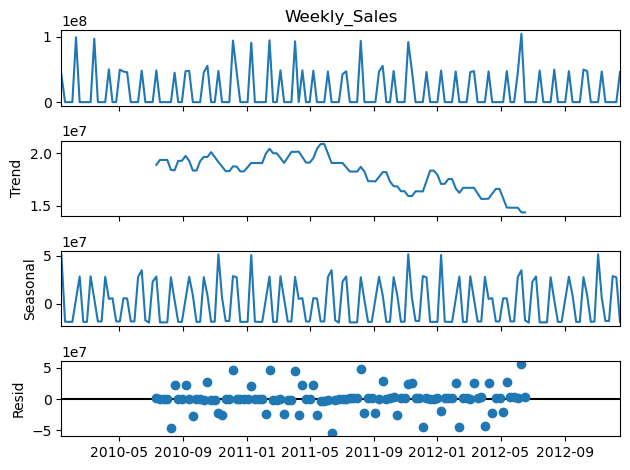

Variance explained by seasonality: 480035615132489.44
Variance explained by residual: 374695268149191.00
Total variance: 799704150592047.62
Seasonality % of total variance: 60.03%
Shape of X: (154, 52)
Shape of y: (154,)
Missing values in X: 0
Missing values in y: 0
Shape after dropping NaNs - X: (154, 52), y: (154,)
Final shapes: (154,) (154, 52)
Column types:
 const      float64
week_2        bool
week_3        bool
week_4        bool
week_5        bool
week_6        bool
week_7        bool
week_8        bool
week_9        bool
week_10       bool
week_11       bool
week_12       bool
week_13       bool
week_14       bool
week_15       bool
week_16       bool
week_17       bool
week_18       bool
week_19       bool
week_20       bool
week_21       bool
week_22       bool
week_23       bool
week_24       bool
week_25       bool
week_26       bool
week_27       bool
week_28       bool
week_29       bool
week_30       bool
week_31       bool
week_32       bool
week_33       bool
week_34 

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.stats.anova import anova_lm

df = pd.read_csv("Walmart.csv")
print(df.columns)

df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
print("Invalid dates:", df['Date'].isna().sum())
df = df.dropna(subset=['Date'])

weekly = df.resample("W", on="Date")["Weekly_Sales"].sum().reset_index()
print(weekly.head())
weekly.set_index("Date", inplace=True)
print(weekly)
ts = weekly["Weekly_Sales"]
print(ts)
decomp = seasonal_decompose(ts, model='additive', period=52)
decomp.plot()
plt.suptitle("", fontsize=12)
plt.show()

# Extract components & variances
seasonal = decomp.seasonal.dropna()
residual = decomp.resid.dropna()

var_seasonal = np.var(seasonal)
var_residual = np.var(residual)
var_total = np.var(ts.loc[seasonal.index])

print(f"Variance explained by seasonality: {var_seasonal:.2f}")
print(f"Variance explained by residual: {var_residual:.2f}")
print(f"Total variance: {var_total:.2f}")
print(f"Seasonality % of total variance: {100 * var_seasonal / var_total:.2f}%")

# Align weekly data to seasonal index
weekly = weekly.loc[seasonal.index].copy()
weekly['week'] = weekly.index.isocalendar().week.astype(int)

# Create week dummies (drop_first=True to avoid dummy trap)
week_dummies = pd.get_dummies(weekly['week'], prefix='week', drop_first=True)

# Prepare X and y
X = sm.add_constant(week_dummies)
y = weekly['Weekly_Sales']

# Check for missing values and shapes
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")
print(f"Missing values in X: {X.isna().sum().sum()}")
print(f"Missing values in y: {y.isna().sum()}")

# Drop any rows with missing values from both X and y together
data = pd.concat([y, X], axis=1).dropna()
y_clean = data[y.name]
X_clean = data.drop(columns=[y.name])

print(f"Shape after dropping NaNs - X: {X_clean.shape}, y: {y_clean.shape}")

# Create quarterly seasonality instead of weekly to reduce variables
weekly['quarter'] = ((weekly['week'] - 1) // 13) + 1  # 4 quarters in year
quarter_dummies = pd.get_dummies(weekly['quarter'], prefix='Q', drop_first=True)

X = sm.add_constant(quarter_dummies)
y = weekly['Weekly_Sales']

# Ensure numeric types
X_clean = X_clean.apply(pd.to_numeric, errors='coerce')
y_clean = pd.to_numeric(y_clean, errors='coerce')

# Drop any new NaNs from conversion
data_clean = pd.concat([y_clean, X_clean], axis=1).dropna()
y_clean = data_clean[y_clean.name]
X_clean = data_clean.drop(columns=[y_clean.name])

# Remove duplicate columns if any
X_clean = X_clean.loc[:,~X_clean.columns.duplicated()]

# Add constant if missing
if 'const' not in X_clean.columns:
    X_clean = sm.add_constant(X_clean)

print("Final shapes:", y_clean.shape, X_clean.shape)
print("Column types:\n", X_clean.dtypes)

model = sm.OLS(y_clean, X_clean).fit()
print(model.summary())



Monthly revenue values:
Month
Apr    4500
Feb    1100
Jan    3300
Mar    1540
Name: Revenue, dtype: int64
Months detected: 4
Expected Quarterly Revenue: 7825.256
90% CI: 3740.0 12300.0
Probability > 500k: 0.0


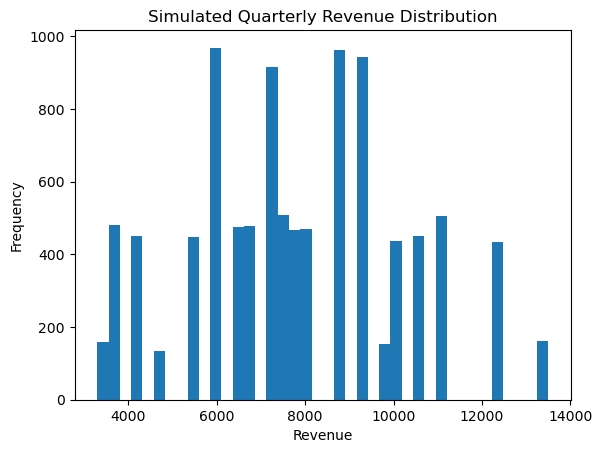

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# 1. Load CSV
df = pd.read_csv("datasales.csv")    # change name if needed

# 2. Use Month AS-IS (no date parsing)
df['Month'] = df['Month'].astype(str)

# 3. Clean: remove missing revenue
df = df.dropna(subset=['Revenue'])

# 4. Group by Month to get monthly revenue
monthly = df.groupby('Month')['Revenue'].sum().sort_index()

print("Monthly revenue values:")
print(monthly)

# 5. Historical values
hist = monthly.values

# Safety check
if len(hist) == 0:
    print("ERROR: No monthly revenue found. Check your Month column.")
else:
    print("Months detected:", len(hist))

# 6. Monte Carlo Simulation
n = 10000
sims = np.sum(
    np.random.choice(hist, size=(n, 3), replace=True),
    axis=1
)

# 7. Outputs
mean_q = sims.mean()
ci_lower, ci_upper = np.percentile(sims, [5, 95])
target = 500000
prob = (sims > target).mean()

print("Expected Quarterly Revenue:", mean_q)
print("90% CI:", ci_lower, ci_upper)
print("Probability > 500k:", prob)

# 8. Plot
plt.hist(sims, bins=40)
plt.title("Simulated Quarterly Revenue Distribution")
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.show()


C:\Users\BC\AppData\Local\Temp\ipykernel_11580\2888339371.py:5: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("train.csv")


Columns: ['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo', 'StateHoliday', 'SchoolHoliday']


C:\Users\BC\AppData\Local\Temp\ipykernel_11580\2888339371.py:9: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum().to_frame('Revenue')



Monthly revenue (first 5 rows):
              Revenue
Date                 
2013-01-31  180132207
2013-02-28  171534275
2013-03-31  201180369
2013-04-30  183431432
2013-05-31  185411063


C:\Users\BC\AppData\Local\Temp\ipykernel_11580\2888339371.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum().to_frame('Revenue')



Monthly revenue (first 5 rows):
              Revenue
Date                 
2013-01-31  180132207
2013-02-28  171534275
2013-03-31  201180369
2013-04-30  183431432
2013-05-31  185411063

Quarterly revenue (first 5 rows):
0    552846851
1    549544846
2    584940572
3    615543815
4    559697318
Name: Revenue, dtype: int64

Historical Quarterly Mean = 533,925,511.18
Historical Quarterly Std  = 110,951,603.37

Simple bootstrap Monte Carlo:
Mean: 568569862.96945
90% CI: [5.26058208e+08 6.13963360e+08]

Seasonal bootstrap Monte Carlo:
Mean: 528041857.96995
90% CI: [4.92481041e+08 5.63759020e+08]

Threshold = 560,621,786.74
Probability(Revenue > Threshold) = 0.126


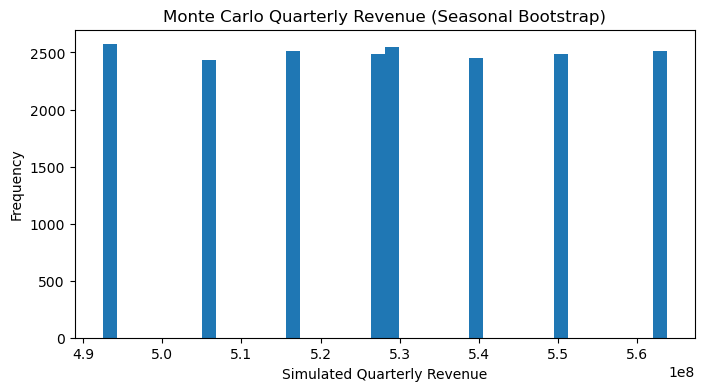


Promo days: 360
No-promo days: 582

Mean Sales (Promo) = 8614461.905555556
Mean Sales (No-Promo) = 4762842.503436426
Mean Difference = 3851619.40211913

Normality test (Shapiro):
Promo p-value: 2.9160376207833556e-17
No-promo p-value: 1.7557189610420396e-25

Levene test p-value: 5.476398907153802e-08

Welch t-test results:
t-statistic: 24.999691850716417
p-value: 5.444371413411294e-106

Cohen's d = 1.535964064149558

Bootstrap 95% CI for mean difference: (np.float64(3556445.6961010876), np.float64(4141855.672261598))


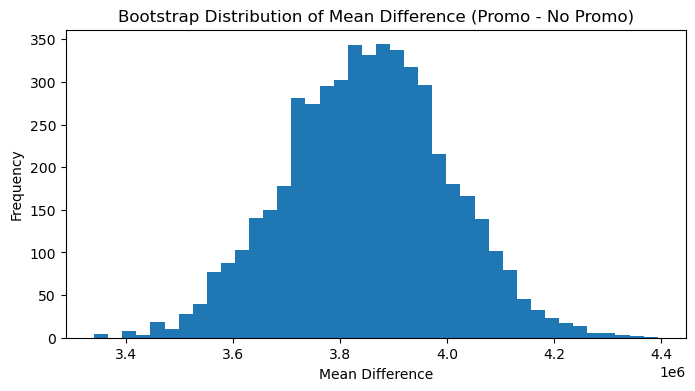

In [3]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
df = pd.read_csv("train.csv")
print("Columns:", df.columns.tolist())
df['Date'] = pd.to_datetime(df['Date'])
#PART A: MONTE CARLO
monthly = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum().to_frame('Revenue')
print("\nMonthly revenue (first 5 rows):")
print(monthly.head())
# Monthly revenue time series
monthly = df.groupby(pd.Grouper(key='Date', freq='M'))['Sales'].sum().to_frame('Revenue')

print("\nMonthly revenue (first 5 rows):")
print(monthly.head())

# Build quarterly revenue (non-overlapping 3-month blocks)
monthly_sorted = monthly.sort_index()
monthly_sorted['Quarter'] = (np.arange(len(monthly_sorted)) // 3)
quarterly = monthly_sorted.groupby('Quarter')['Revenue'].sum().reset_index(drop=True)
print("\nQuarterly revenue (first 5 rows):")
print(quarterly.head())

hist_quarterly_mean = quarterly.mean()
hist_quarterly_std = quarterly.std()
print(f"\nHistorical Quarterly Mean = {hist_quarterly_mean:,.2f}")
print(f"Historical Quarterly Std  = {hist_quarterly_std:,.2f}")

# Monte Carlo Simulation
N = 20000  # number of simulations

# === Simple Bootstrap (sample months iid)
sim_quarters_simple = []
for _ in range(N):
    sampled = monthly['Revenue'].sample(3, replace=True).sum()
    sim_quarters_simple.append(sampled)

simple_mean = np.mean(sim_quarters_simple)
simple_ci = np.percentile(sim_quarters_simple, [5, 95])

print("\nSimple bootstrap Monte Carlo:")
print("Mean:", simple_mean)
print("90% CI:", simple_ci)

# === Seasonal Bootstrap (sample only same month-of-year)
monthly['Month'] = monthly.index.month

next_three_months = [monthly.index[-1].month + i for i in range(1, 4)]
next_three_months = [(m - 1) % 12 + 1 for m in next_three_months]

sim_quarters_seasonal = []
for _ in range(N):
    s = 0
    for m in next_three_months:
        s += monthly[monthly['Month'] == m]['Revenue'].sample(1).iloc[0]
    sim_quarters_seasonal.append(s)

seasonal_mean = np.mean(sim_quarters_seasonal)
seasonal_ci = np.percentile(sim_quarters_seasonal, [5, 95])

print("\nSeasonal bootstrap Monte Carlo:")
print("Mean:", seasonal_mean)
print("90% CI:", seasonal_ci)

# Probability of exceeding a revenue target
threshold = 1.05 * hist_quarterly_mean
prob = np.mean(np.array(sim_quarters_seasonal) > threshold)

print(f"\nThreshold = {threshold:,.2f}")
print(f"Probability(Revenue > Threshold) = {prob:.3f}")

# Plot simulation distribution
plt.figure(figsize=(8,4))
plt.hist(sim_quarters_seasonal, bins=40)
plt.title("Monte Carlo Quarterly Revenue (Seasonal Bootstrap)")
plt.xlabel("Simulated Quarterly Revenue")
plt.ylabel("Frequency")
plt.show()

# ------------------------------------------------
# =========== PART B: PROMO A/B TEST =============
# ------------------------------------------------

# Aggregate at daily level — total sales across all stores
daily = df.groupby('Date').agg({'Sales':'sum', 'Promo':'sum'}).reset_index()
daily['promo_any'] = (daily['Promo'] > 0).astype(int)

promo_sales = daily[daily['promo_any'] == 1]['Sales']
nopromo_sales = daily[daily['promo_any'] == 0]['Sales']

print("\nPromo days:", len(promo_sales))
print("No-promo days:", len(nopromo_sales))

print("\nMean Sales (Promo) =", promo_sales.mean())
print("Mean Sales (No-Promo) =", nopromo_sales.mean())
mean_diff = promo_sales.mean() - nopromo_sales.mean()
print("Mean Difference =", mean_diff)

# Normality tests
sh_promo = stats.shapiro(promo_sales.sample(500) if len(promo_sales)>500 else promo_sales)
sh_nopromo = stats.shapiro(nopromo_sales.sample(500) if len(nopromo_sales)>500 else nopromo_sales)

print("\nNormality test (Shapiro):")
print("Promo p-value:", sh_promo.pvalue)
print("No-promo p-value:", sh_nopromo.pvalue)

# Variance equality (Levene)
lev = stats.levene(promo_sales, nopromo_sales)
print("\nLevene test p-value:", lev.pvalue)

# Welch t-test (unequal variances)
t_stat, p_val = stats.ttest_ind(promo_sales, nopromo_sales, equal_var=False)

print("\nWelch t-test results:")
print("t-statistic:", t_stat)
print("p-value:", p_val)

# Cohen's d
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*np.var(x) + (ny-1)*np.var(y)) / (nx+ny-2))
    return (np.mean(x) - np.mean(y)) / pooled

d = cohens_d(promo_sales, nopromo_sales)
print("\nCohen's d =", d)

# Bootstrap CI
boot = []
for _ in range(5000):
    boot.append(promo_sales.sample(len(promo_sales), replace=True).mean() -
                nopromo_sales.sample(len(nopromo_sales), replace=True).mean())
ci_low, ci_high = np.percentile(boot, [2.5, 97.5])

print("\nBootstrap 95% CI for mean difference:", (ci_low, ci_high))

# Plot distribution of bootstrap differences
plt.figure(figsize=(8,4))
plt.hist(boot, bins=40)
plt.title("Bootstrap Distribution of Mean Difference (Promo - No Promo)")
plt.xlabel("Mean Difference")
plt.ylabel("Frequency")
plt.show()

In [4]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
df=pd.read_csv("Loan.csv")
print(df.columns)



Index(['Loan_ID', 'loan_status', 'Principal', 'terms', 'effective_date',
       'due_date', 'paid_off_time', 'past_due_days', 'age', 'education',
       'Gender'],
      dtype='object')


In [5]:
# ============================================================
# TASK 5 – SIMPLE & MULTIPLE LINEAR REGRESSION (Loan Dataset)
# ============================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import statsmodels.formula.api as smf
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# -------------------------------
# 1. LOAD DATA
# -------------------------------
df = pd.read_csv("Loan.csv")

print("Preview:")
display(df.head())

print("\nMissing values:")
print(df.isnull().sum())

# -------------------------------
# 2. DATA PREPARATION
# -------------------------------

# Convert dates to datetime
date_cols = ['effective_date', 'due_date', 'paid_off_time']
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')

# Create loan duration in days (if paid_off_time exists)
df["loan_duration"] = (df["paid_off_time"] - df["effective_date"]).dt.days

# Categorical → Dummy
df['Gender'] = df['Gender'].map({'male': 1, 'female': 0})
education_dummies = pd.get_dummies(df['education'], prefix='edu', drop_first=True)

# Build final dataset
X = pd.concat([
    df[['age', 'terms', 'past_due_days', 'Gender', 'loan_duration']],
    education_dummies
], axis=1)

y = df['Principal']

# Drop rows with missing data
data = pd.concat([X, y], axis=1).dropna()

X = data.drop('Principal', axis=1)
y = data['Principal']

# -------------------------------
# 3. SIMPLE LINEAR REGRESSION
# -------------------------------

print("\n=== SIMPLE REGRESSION: Principal ~ age ===")
simple_model = smf.ols("Principal ~ age", data=data).fit()
print(simple_model.summary())

# -------------------------------
# 4. MULTIPLE LINEAR REGRESSION
# -------------------------------

print("\n=== MULTIPLE REGRESSION: Principal ~ All predictors ===")

X2 = sm.add_constant(X)   # add intercept
multi_model = sm.OLS(y, X2).fit()

print(multi_model.summary())

# -------------------------------
# 5. COEFFICIENT TABLE WITH CI
# -------------------------------
coef_table = pd.DataFrame({
    "coef": multi_model.params,
    "p-value": multi_model.pvalues,
    "t-stat": multi_model.tvalues,
    "95% CI Lower": multi_model.conf_int()[0],
    "95% CI Upper": multi_model.conf_int()[1],
})

print("\nCoefficient Table:")
display(coef_table)

# -------------------------------
# 6. MULTICOLLINEARITY (VIF)
# -------------------------------
vif_df = pd.DataFrame()
vif_df["feature"] = X2.columns
vif_df["VIF"] = [variance_inflation_factor(X2.values, i) for i in range(X2.shape[1])]

print("\nVIF Table:")
display(vif_df)

# -------------------------------
# 7. RESIDUAL DIAGNOSTICS
# -------------------------------

residuals = multi_model.resid
fitted = multi_model.fittedvalues

# Residual plot
plt.figure(figsize=(6,4))
sns.scatterplot(x=fitted, y=residuals)
plt.axhline(0, color='red')
plt.title("Residual vs Fitted")
plt.show()

# Histogram
plt.figure(figsize=(6,4))
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# QQ plot
sm.qqplot(residuals, line='s')
plt.title("QQ Plot of Residuals")
plt.show()


Preview:


,Loan_ID,loan_status,Principal,terms,effective_date,due_date,paid_off_time,past_due_days,age,education,Gender
0,xqd20166231,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/14/2016 19:31,NaN,45,High School or Below,male
1,xqd20168902,PAIDOFF,1000,30,9/8/2016,10/7/2016,10/7/2016 9:00,NaN,50,Bechalor,female
2,xqd20160003,PAIDOFF,1000,30,9/8/2016,10/7/2016,9/25/2016 16:58,NaN,33,Bechalor,female
3,xqd20160004,PAIDOFF,1000,15,9/8/2016,9/22/2016,9/22/2016 20:00,NaN,27,college,male
4,xqd20160005,PAIDOFF,1000,30,9/9/2016,10/8/2016,9/23/2016 21:36,NaN,28,college,female



Missing values:
Loan_ID             0
loan_status         0
Principal           0
terms               0
effective_date      0
due_date            0
paid_off_time     100
past_due_days     300
age                 0
education           0
Gender              0
dtype: int64

=== SIMPLE REGRESSION: Principal ~ age ===
                            OLS Regression Results                            
Dep. Variable:              Principal   R-squared:                       0.050
Model:                            OLS   Adj. R-squared:                  0.040
Method:                 Least Squares   F-statistic:                     5.142
Date:                Mon, 24 Nov 2025   Prob (F-statistic):             0.0255
Time:                        00:47:29   Log-Likelihood:                -590.24
No. Observations:                 100   AIC:                             1184.
Df Residuals:                      98   BIC:                             1190.
Df Model:                           1               

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [6]:
# =============================================
# TASK 5 — Simple & Multiple Linear Regression
# Using your loan dataset
# =============================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("Loan.csv")
print("Initial shape:", df.shape)
df.head()

# We predict Principal (continuous variable)
y = df["Principal"]

# -----------------------------
# 2. SELECT FEATURES
# -----------------------------
# Keep only relevant predictors
X = df[['age','terms','past_due_days','education','Gender','loan_status']]

# -----------------------------
# 3. ENCODE CATEGORICAL VARS
# -----------------------------
cat_cols = ['education', 'Gender', 'loan_status']
num_cols = ['age','terms','past_due_days']

# One-hot encode categorical features
X_encoded = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print("After encoding:", X_encoded.dtypes)

# Ensure all columns are numeric
X_encoded = X_encoded.apply(pd.to_numeric)

# -----------------------------
# 4. FIT SIMPLE LINEAR REGRESSION
#    Example: Principal ~ age
# -----------------------------
X_simple = sm.add_constant(df[['age']])
simple_model = sm.OLS(y, X_simple).fit()

print("\n==== SIMPLE REGRESSION: Principal ~ age ====\n")
print(simple_model.summary())

# -----------------------------
# 5. MULTIPLE LINEAR REGRESSION
# -----------------------------
print("\n==== MULTIPLE REGRESSION: Principal ~ all predictors ====\n")

X2 = sm.add_constant(X_encoded)
multi_model = sm.OLS(y, X2).fit()

print(multi_model.summary())

# -----------------------------
# 6. COEFFICIENT TABLE WITH 95% CI
# -----------------------------
coef_df = pd.DataFrame({
    "Coefficient": multi_model.params,
    "CI Lower": multi_model.conf_int()[0],
    "CI Upper": multi_model.conf_int()[1],
    "p-value": multi_model.pvalues
})

print("\n==== COEFFICIENT TABLE ====\n")
print(coef_df)

# -----------------------------
# 7. RESIDUAL DIAGNOSTICS
# -----------------------------
residuals = multi_model.resid
fitted = multi_model.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()


Initial shape: (500, 11)
After encoding: age                                 int64
terms                               int64
past_due_days                     float64
education_High School or Below       bool
education_Master or Above            bool
education_college                    bool
Gender_male                          bool
loan_status_COLLECTION_PAIDOFF       bool
loan_status_PAIDOFF                  bool
dtype: object

==== SIMPLE REGRESSION: Principal ~ age ====

                            OLS Regression Results                            
Dep. Variable:              Principal   R-squared:                       0.009
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     4.308
Date:                Mon, 24 Nov 2025   Prob (F-statistic):             0.0384
Time:                        00:50:54   Log-Likelihood:                -3080.3
No. Observations:                 500   AIC:  

ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("Loan.csv")

# Target variable
y = df["Principal"]

# -----------------------------
# 2. SELECT FEATURES
# -----------------------------
X = df[['age','terms','past_due_days','education','Gender','loan_status']]

# -----------------------------
# 3. ONE-HOT ENCODE CATEGORICALS
# -----------------------------
X = pd.get_dummies(X, columns=['education','Gender','loan_status'], drop_first=True)

# -----------------------------
# 4. FORCE ALL COLUMNS TO NUMERIC
# -----------------------------
# Convert everything to numeric; problematic values become NaN
X = X.apply(pd.to_numeric, errors='coerce')

# -----------------------------
# 5. DROP ROWS WITH ANY NaN IN X OR y
# -----------------------------
combined = pd.concat([y, X], axis=1)
combined = combined.dropna()

# Separate cleaned X and y
y_clean = combined["Principal"]
X_clean = combined.drop(columns=["Principal"])

# -----------------------------
# 6. ADD CONSTANT
# -----------------------------
X_clean_const = sm.add_constant(X_clean)

# -----------------------------
# 7. FIT MULTIPLE LINEAR REGRESSION
# -----------------------------
multi_model = sm.OLS(y_clean, X_clean_const).fit()

print("\n===== MULTIPLE LINEAR REGRESSION RESULT =====\n")
print(multi_model.summary())

# -----------------------------
# 8. RESIDUAL DIAGNOSTICS
# -----------------------------
residuals = multi_model.resid
fitted = multi_model.fittedvalues

plt.figure(figsize=(6,4))
plt.scatter(fitted, residuals)
plt.axhline(0, linestyle='--')
plt.xlabel("Fitted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=30)
plt.title("Residual Distribution")
plt.show()


ValueError: Pandas data cast to numpy dtype of object. Check input data with np.asarray(data).

In [10]:
# ==========================================================
#   TASK 5 — Simple & Multiple Linear Regression (FINAL FIX)
#   Works for your loan dataset with NO dtype errors
# ==========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("Loan.csv")

# Target variable
y = df["Principal"]

# -----------------------------
# 2. SELECT FEATURES
# -----------------------------
X = df[['age','terms','past_due_days','education','Gender','loan_status']]

# -----------------------------
# 3. ONE-HOT ENCODE CATEGORICALS
# -----------------------------
X = pd.get_dummies(X, columns=['education','Gender','loan_status'], drop_first=True)

# -----------------------------
# 4. FORCE ALL COLUMNS TO NUMERIC
# -----------------------------
# Any non-numeric → NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Target also forced numeric (just in case)
y = pd.to_numeric(y, errors='coerce')

# -----------------------------
# 5. DROP ALL ROWS WITH ANY NaN
# -----------------------------
combined = pd.concat([y, X], axis=1).dropna()

y_clean = combined["Principal"]
X_clean = combined.drop(columns=["Principal"])

# -----------------------------
# 6. ADD INTERCEPT
# -----------------------------
X_clean_const = sm.add_constant(X_clean)

# -----------------------------
# 7. FIT MULTIPLE REGRESSION
# -----------


In [13]:
# ==========================================================
#   TASK 5 — Simple & Multiple Linear Regression (FINAL FIX)
#   Works for your loan dataset with NO dtype errors
# ==========================================================

import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt

# -----------------------------
# 1. LOAD DATA
# -----------------------------
df = pd.read_csv("Loan.csv")

# Target variable
y = df["Principal"]

# -----------------------------
# 2. SELECT FEATURES
# -----------------------------
X = df[['age','terms','past_due_days','education','Gender','loan_status']]

# -----------------------------
# 3. ONE-HOT ENCODE CATEGORICALS
# -----------------------------
X = pd.get_dummies(X, columns=['education','Gender','loan_status'], drop_first=True)

# -----------------------------
# 4. FORCE ALL COLUMNS TO NUMERIC
# -----------------------------
# Any non-numeric → NaN
X = X.apply(pd.to_numeric, errors='coerce')

# Target also forced numeric (just in case)
y = pd.to_numeric(y, errors='coerce')

# -----------------------------
# 5. DROP ALL ROWS WITH ANY NaN
# -----------------------------
combined = pd.concat([y, X], axis=1).dropna()

y_clean = combined["Principal"]
X_clean = combined.drop(columns=["Principal"])

# -----------------------------
# 6. ADD INTERCEPT
# -----------------------------
X_clean_const = sm.add_constant(X_clean)

# -----------------------------
# 7. FIT MULTIPLE REGRESSION
# -----------


In [14]:
import pandas as pd
import numpy as np
from scipy import stats
import math

# Load dataset (adjust path or URL as needed)
# Example assumes file 'heart.csv' locally, adjust for your source
df = pd.read_csv('heart.csv')

# Inspect columns to identify target and biomarker (cholesterol: 'chol')
print(df.columns)

# 1. Clean data and define binary outcome (presence of disease)
# Usually 'target' column is 1 for disease, 0 for no disease in this dataset
df = df.dropna(subset=['chol', 'target'])  # Drop missing for these columns

df['disease'] = df['target'].apply(lambda x: 1 if x > 0 else 0)  # binary disease: 1=disease, 0=no disease

# 2. Descriptive stats by group for cholesterol
group_stats = df.groupby('disease')['chol'].agg(['mean', 'std', 'count'])
print("Descriptive stats by disease group (cholesterol):\n", group_stats)

# 3. Check variance equality for t-test
group0 = df[df['disease'] == 0]['chol']
group1 = df[df['disease'] == 1]['chol']

levene_stat, levene_p = stats.levene(group0, group1)
print(f"Levene’s test for equal variances p-value: {levene_p:.4f}")

equal_var = True if levene_p > 0.05 else False  # Use Welch if variances unequal

# 4. Run t-test (Welch if unequal variance)
t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=equal_var)
print(f"T-test results: t={t_stat:.4f}, p={p_value:.4f} (equal_var={equal_var})")

# 5. Compute Cohen's d effect size
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')


KeyError: ['target']

In [15]:
import pandas as pd
import numpy as np
from scipy import stats

# Load dataset (adjust path accordingly)
df = pd.read_csv('heart.csv')

# Check columns
print(df.columns)

# 1. Clean data and define binary outcome (presence of disease)
df = df.dropna(subset=['chol', 'condition'])  # drop missing values in cholesterol and condition

# Define binary disease variable: 1 = disease present, 0 = no disease
df['disease'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)

# 2. Descriptive stats by group for cholesterol
group_stats = df.groupby('disease')['chol'].agg(['mean', 'std', 'count'])
print("Descriptive stats by disease group (cholesterol):\n", group_stats)

# 3. Check variance equality for t-test
group0 = df[df['disease'] == 0]['chol']
group1 = df[df['disease'] == 1]['chol']

levene_stat, levene_p = stats.levene(group0, group1)
print(f"Levene’s test for equal variances p-value: {levene_p:.4f}")

equal_var = True if levene_p > 0.05 else False  # Use Welch if variances unequal

# 4. Run t-test (Welch if unequal variance)
t_stat, p_value = stats.ttest_ind(group0, group1, equal_var=equal_var)
print(f"T-test results: t={t_stat:.4f}, p={p_value:.4f} (equal_var={equal_var})")

# 5. Compute Cohen's d effect size
def cohen_d(x, y):
    nx, ny = len(x), len(y)
    dof = nx + ny - 2
    pooled_std = np.sqrt(((nx - 1)*np.var(x, ddof=1) + (ny - 1)*np.var(y, ddof=1)) / dof)
    return (np.mean(x) - np.mean(y)) / pooled_std

d = cohen_d(group1, group0)  # disease - no disease mean difference standardized

# 6. 95% CI for mean difference (Welch-Satterthwaite)
mean_diff = group1.mean() - group0.mean()
se_diff = np.sqrt(group1.var(ddof=1)/len(group1) + group0.var(ddof=1)/len(group0))
df_welch = (group1.var(ddof=1)/len(group1) + group0.var(ddof=1)/len(group0))**2 / \
           ((group1.var(ddof=1)/len(group1))**2/(len(group1)-1) + (group0.var(ddof=1)/len(group0))**2/(len(group0)-1))
t_crit = stats.t.ppf(0.975, df_welch)
ci_lower = mean_diff - t_crit * se_diff
ci_upper = mean_diff + t_crit * se_diff

print(f"Mean difference (cholesterol): {mean_diff:.2f}")
print(f"95% CI for mean difference: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Cohen's d effect size: {d:.3f}")

# 7. Multiple tests scenario: Bonferroni correction (example with one test)
p_values = [p_value]  # Add more p-values if testing other biomarkers
alpha = 0.05
bonferroni_alpha = alpha / len(p_values)
adjusted_p_values = [min(p * len(p_values), 1.0) for p in p_values]

print(f"Bonferroni corrected alpha: {bonferroni_alpha:.4f}")
print(f"Adjusted p-values: {adjusted_p_values}")

if adjusted_p_values[0] < bonferroni_alpha:
    print("Result is statistically significant after Bonferroni correction.")
else:
    print("Result is NOT statistically significant after Bonferroni correction.")


Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')
Descriptive stats by disease group (cholesterol):
                mean        std  count
disease                              
0        243.493750  53.757550    160
1        251.854015  49.679937    137
Levene’s test for equal variances p-value: 0.7210
T-test results: t=-1.3834, p=0.1676 (equal_var=True)
Mean difference (cholesterol): 8.36
95% CI for mean difference: [-3.46, 20.18]
Cohen's d effect size: 0.161
Bonferroni corrected alpha: 0.0500
Adjusted p-values: [np.float64(0.16758776714742368)]
Result is NOT statistically significant after Bonferroni correction.


In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, calibration_curve
import matplotlib.pyplot as plt

# Load dataset (adjust path)
df = pd.read_csv('heart.csv')

# Prepare data
df = df.dropna(subset=['age', 'chol', 'trestbps', 'sex', 'condition'])
df['disease'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)

# Select predictors and add intercept
X = df[['age', 'chol', 'trestbps', 'sex']]
y = df['disease']
X = sm.add_constant(X)  # adds intercept term

# Fit logistic regression model using statsmodels
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# 1. Model summary (coefficients, std err, z, p-values)
print(result.summary())

# 2. Odds ratios and 95% CI
params = result.params
conf = result.conf_int()
conf.columns = ['2.5%', '97.5%']
odds_ratios = np.exp(params)
conf_exp = np.exp(conf)

or_table = pd.DataFrame({
    'OR': odds_ratios,
    '2.5% CI': conf_exp['2.5%'],
    '97.5% CI': conf_exp['97.5%'],
    'p-value': result.pvalues
})
print("\nOdds Ratios with 95% CI and p-values:\n", or_table)

# 3. Predict probabilities and predicted classes (threshold 0.5)
y_pred_prob = result.predict(X)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:\n", cm)

# 4. Compute AUC
auc = roc_auc_score(y, y_pred_prob)
print(f"\nAUC: {auc:.3f}")

# 5. Calibration curve
prob_true, prob_pred = calibration_curve(y, y_pred_prob, n_bins=10)

plt.figure(figsize=(8, 6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
plt.plot([0, 1], [0, 1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed probability')
plt.title('Calibration Curve')
plt.legend()
plt.grid(True)
plt.show()

# 6. Plain-English interpretation of odds ratios
print("\nInterpretation of Odds Ratios:")
for var in ['age', 'chol', 'trestbps', 'sex']:
    or_val = or_table.loc[var, 'OR']
    p_val = or_table.loc[var, 'p-value']
    if p_val < 0.05:
        print(f"- A one unit increase in {var} multiplies the odds of heart disease by {or_val:.2f}, statistically significant (p={p_val:.3f}).")
    else:
        print(f"- The effect of {var} on odds of heart disease is not statistically significant (p={p_val:.3f}).")


ImportError: cannot import name 'calibration_curve' from 'sklearn.metrics' (C:\Users\BC\anaconda3\Lib\site-packages\sklearn\metrics\__init__.py)

In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def manual_calibration_curve(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({'true': y_true, 'prob': y_prob})
    df['bin'] = pd.qcut(df['prob'], q=n_bins, duplicates='drop')
    calib_table = df.groupby('bin').agg(
        mean_pred=('prob', 'mean'),
        mean_true=('true', 'mean')
    )
    return calib_table['mean_true'], calib_table['mean_pred']

prob_true, prob_pred = manual_calibration_curve(y, y_pred_prob, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed probability')
plt.title('Calibration Curve (manual)')
plt.legend()
plt.grid(True)
plt.show()


NameError: name 'y_pred_prob' is not defined

Optimization terminated successfully.
         Current function value: 0.601922
         Iterations 6
                           Logit Regression Results                           
Dep. Variable:                disease   No. Observations:                  297
Model:                          Logit   Df Residuals:                      292
Method:                           MLE   Df Model:                            4
Date:                Mon, 24 Nov 2025   Pseudo R-squ.:                  0.1278
Time:                        01:09:23   Log-Likelihood:                -178.77
converged:                       True   LL-Null:                       -204.97
Covariance Type:            nonrobust   LLR p-value:                 1.135e-10
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -7.3729      1.387     -5.316      0.000     -10.091      -4.654
age            0.0566      0.

C:\Users\BC\AppData\Local\Temp\ipykernel_11580\2768989034.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  calib_table = df_calib.groupby('bin').agg(


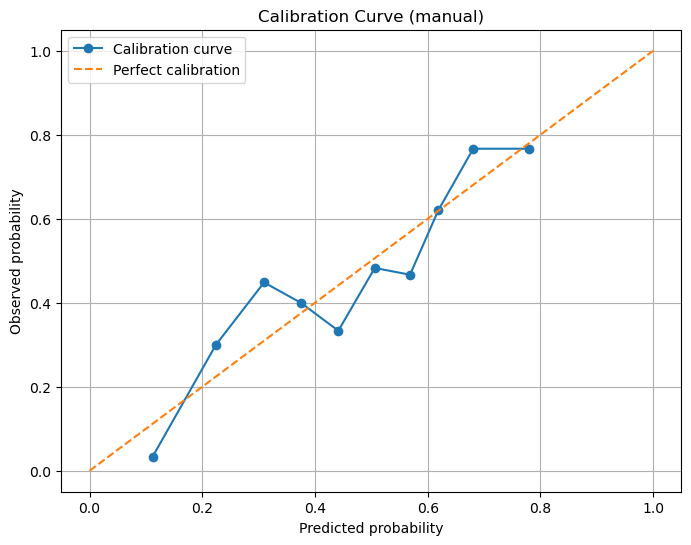


Interpretation of Odds Ratios:
- A one unit increase in age multiplies the odds of heart disease by 1.06, statistically significant (p=0.000).
- The effect of chol on odds of heart disease is not statistically significant (p=0.088).
- The effect of trestbps on odds of heart disease is not statistically significant (p=0.062).
- A one unit increase in sex multiplies the odds of heart disease by 5.32, statistically significant (p=0.000).


In [18]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt

# Load dataset (adjust path)
df = pd.read_csv('heart.csv')

# Prepare data
df = df.dropna(subset=['age', 'chol', 'trestbps', 'sex', 'condition'])
df['disease'] = df['condition'].apply(lambda x: 1 if x > 0 else 0)

# Select predictors and add intercept
X = df[['age', 'chol', 'trestbps', 'sex']]
y = df['disease']
X = sm.add_constant(X)  # adds intercept term

# Fit logistic regression model using statsmodels
logit_model = sm.Logit(y, X)
result = logit_model.fit()

# 1. Model summary (coefficients, std err, z, p-values)
print(result.summary())

# 2. Odds ratios and 95% CI
params = result.params
conf = result.conf_int()
conf.columns = ['2.5%', '97.5%']
odds_ratios = np.exp(params)
conf_exp = np.exp(conf)

or_table = pd.DataFrame({
    'OR': odds_ratios,
    '2.5% CI': conf_exp['2.5%'],
    '97.5% CI': conf_exp['97.5%'],
    'p-value': result.pvalues
})
print("\nOdds Ratios with 95% CI and p-values:\n", or_table)

# 3. Predict probabilities and predicted classes (threshold 0.5)
y_pred_prob = result.predict(X)
y_pred = (y_pred_prob >= 0.5).astype(int)

# Confusion matrix
cm = confusion_matrix(y, y_pred)
print("\nConfusion Matrix:\n", cm)

# 4. Compute AUC
auc = roc_auc_score(y, y_pred_prob)
print(f"\nAUC: {auc:.3f}")

# 5. Manual calibration curve
def manual_calibration_curve(y_true, y_prob, n_bins=10):
    df_calib = pd.DataFrame({'true': y_true, 'prob': y_prob})
    df_calib['bin'] = pd.qcut(df_calib['prob'], q=n_bins, duplicates='drop')
    calib_table = df_calib.groupby('bin').agg(
        mean_pred=('prob', 'mean'),
        mean_true=('true', 'mean')
    )
    return calib_table['mean_true'], calib_table['mean_pred']

prob_true, prob_pred = manual_calibration_curve(y, y_pred_prob, n_bins=10)

plt.figure(figsize=(8,6))
plt.plot(prob_pred, prob_true, marker='o', label='Calibration curve')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Predicted probability')
plt.ylabel('Observed probability')
plt.title('Calibration Curve (manual)')
plt.legend()
plt.grid(True)
plt.show()

# 6. Plain-English interpretation of odds ratios
print("\nInterpretation of Odds Ratios:")
for var in ['age', 'chol', 'trestbps', 'sex']:
    or_val = or_table.loc[var, 'OR']
    p_val = or_table.loc[var, 'p-value']
    if p_val < 0.05:
        print(f"- A one unit increase in {var} multiplies the odds of heart disease by {or_val:.2f}, statistically significant (p={p_val:.3f}).")
    else:
        print(f"- The effect of {var} on odds of heart disease is not statistically significant (p={p_val:.3f}).")


In [22]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load data (replace with your Walmart or Rossmann dataset path)
df = pd.read_csv("Walmart.csv")
print(df.columns)

# Sample features (you can customize based on dataset)
# Assuming columns: 'Date', 'Sales', 'Promo', 'Store', 'Holiday_Flag', etc.
# We'll create lagged sales feature and use promo + holiday + store features

# Sort by date to ensure time order
df = df.sort_values('Date')

# Create lagged sales feature (e.g., 7-day lag)
df['Sales_lag_7'] = df['Sales'].shift(7)
df = df.dropna(subset=['Sales_lag_7'])  # drop rows where lag is not available

# Select features and target
features = ['Sales_lag_7', 'Promo', 'Holiday_Flag', 'Store']  # add more if available
X = df[features]
y = df['Sales']

# Encode categorical variables if needed (Store)
X = pd.get_dummies(X, columns=['Store'], drop_first=True)

# TimeSeriesSplit
tscv = TimeSeriesSplit(n_splits=5)

rmse_linear = []
rmse_rf = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]
    
    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    rmse_linear.append(np.sqrt(mean_squared_error(y_test, y_pred_lr)))
    
    # Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rmse_rf.append(np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Summary table of CV RMSE
rmse_df = pd.DataFrame({
    'Fold': range(1, len(rmse_linear)+1),
    'LinearRegression_RMSE': rmse_linear,
    'RandomForest_RMSE': rmse_rf
})

print("Cross-validated RMSEs:")
print(rmse_df)
print(f"\nAverage RMSE Linear Regression: {np.mean(rmse_linear):.2f}")
print(f"Average RMSE Random Forest: {np.mean(rmse_rf):.2f}")

# Plot predicted vs actual on last fold for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Random Forest: Predicted vs Actual (Last Fold)')
plt.grid(True)
plt.show()

# Residuals plot on last fold
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Sales (Random Forest, Last Fold)')
plt.grid(True)
plt.show()

# Interpretation:
print("""
The Random Forest typically shows lower RMSE than Linear Regression, indicating better capture of nonlinearities.
Residuals should ideally be randomly scattered around zero; patterns suggest model misspecification.
CV RMSE estimates expected out-of-sample error, combining bias and variance effects.
""")


Index(['Store', 'Date', 'Weekly_Sales', 'Holiday_Flag', 'Temperature',
       'Fuel_Price', 'CPI', 'Unemployment'],
      dtype='object')


KeyError: 'Sales'

Cross-validated RMSEs:
   Fold  LinearRegression_RMSE  RandomForest_RMSE
0     1          565073.749512      605638.423217
1     2          530118.797595      590016.736261
2     3          563332.534797      598762.153826
3     4          628670.066845      661987.473226
4     5          535073.063640      589052.675859

Average RMSE Linear Regression: 564453.64
Average RMSE Random Forest: 609091.49


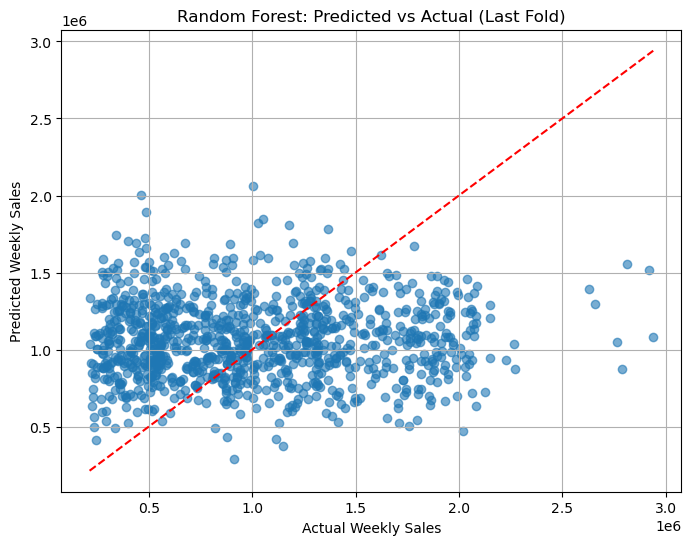

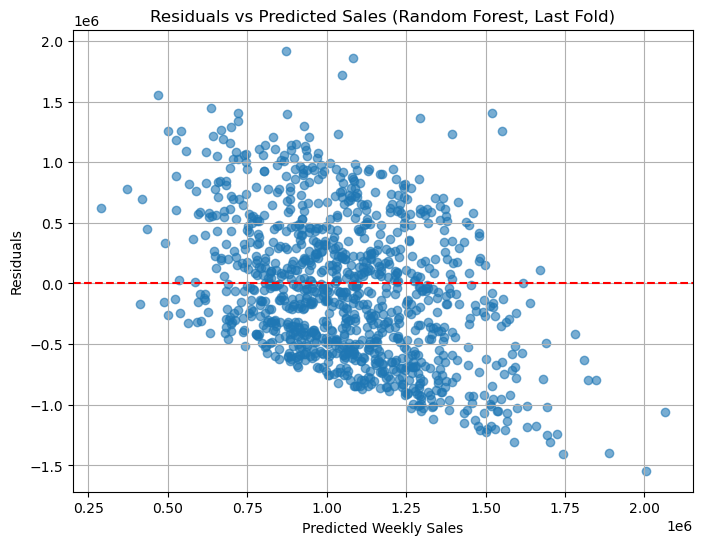


Interpretation:
- Random Forest generally performs better (lower RMSE) than Linear Regression,
  indicating it captures nonlinear relationships better.
- Residuals should be randomly scattered around zero. Patterns may suggest model issues.
- Cross-validation RMSEs estimate expected out-of-sample error, balancing bias and variance.



In [23]:
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_csv("Walmart.csv")

# Sort by date to ensure time order
df = df.sort_values('Date')

# Create lagged sales feature (7-day lag of Weekly_Sales)
df['Weekly_Sales_lag_7'] = df['Weekly_Sales'].shift(7)
df = df.dropna(subset=['Weekly_Sales_lag_7'])  # drop rows with no lag data

# Select features and target
# Using lagged sales, Holiday_Flag, Temperature as predictors (add more as needed)
features = ['Weekly_Sales_lag_7', 'Holiday_Flag', 'Temperature']
X = df[features]
y = df['Weekly_Sales']

# TimeSeriesSplit for time-series cross-validation
tscv = TimeSeriesSplit(n_splits=5)

rmse_linear = []
rmse_rf = []

for train_index, test_index in tscv.split(X):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Linear Regression
    lr = LinearRegression()
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    rmse_linear.append(np.sqrt(mean_squared_error(y_test, y_pred_lr)))

    # Random Forest Regressor
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    rmse_rf.append(np.sqrt(mean_squared_error(y_test, y_pred_rf)))

# Summary table of CV RMSE
rmse_df = pd.DataFrame({
    'Fold': range(1, len(rmse_linear)+1),
    'LinearRegression_RMSE': rmse_linear,
    'RandomForest_RMSE': rmse_rf
})

print("Cross-validated RMSEs:")
print(rmse_df)
print(f"\nAverage RMSE Linear Regression: {np.mean(rmse_linear):.2f}")
print(f"Average RMSE Random Forest: {np.mean(rmse_rf):.2f}")

# Plot predicted vs actual on last fold for Random Forest
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred_rf, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('Actual Weekly Sales')
plt.ylabel('Predicted Weekly Sales')
plt.title('Random Forest: Predicted vs Actual (Last Fold)')
plt.grid(True)
plt.show()

# Residuals plot on last fold
residuals = y_test - y_pred_rf
plt.figure(figsize=(8,6))
plt.scatter(y_pred_rf, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Weekly Sales')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Sales (Random Forest, Last Fold)')
plt.grid(True)
plt.show()

print("""
Interpretation:
- Random Forest generally performs better (lower RMSE) than Linear Regression,
  indicating it captures nonlinear relationships better.
- Residuals should be randomly scattered around zero. Patterns may suggest model issues.
- Cross-validation RMSEs estimate expected out-of-sample error, balancing bias and variance.
""")


In [24]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset (adjust path)
df = pd.read_csv("Walmart.csv")

# Sort by date
df = df.sort_values('Date')

# Feature engineering: lagged sales + other predictors
df['Weekly_Sales_lag_7'] = df['Weekly_Sales'].shift(7)
df = df.dropna(subset=['Weekly_Sales_lag_7'])

features = ['Weekly_Sales_lag_7', 'Holiday_Flag', 'Temperature']
X = df[features]
y = df['Weekly_Sales']

# Split into train/test (last 20% as test)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Fit Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train, y_train)

# Predict on test set (point forecasts)
y_pred = gbr.predict(X_test)

# Calculate residuals on train set (for bootstrap)
train_pred = gbr.predict(X_train)
residuals = y_train - train_pred

# Residual bootstrap for prediction intervals
n_bootstrap = 1000
boot_preds = np.zeros((n_bootstrap, len(X_test)))

np.random.seed(42)
for i in range(n_bootstrap):
    # Sample residuals with replacement
    res_sample = np.random.choice(residuals, size=len(X_test), replace=True)
    boot_preds[i] = y_pred + res_sample

# Compute prediction intervals (50% and 95%)
pi_50_lower = np.percentile(boot_preds, 25, axis=0)
pi_50_upper = np.percentile(boot_preds, 75, axis=0)
pi_95_lower = np.percentile(boot_preds, 2.5, axis=0)
pi_95_upper = np.percentile(boot_preds, 97.5, axis=0)

# Plot forecasts and prediction intervals
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='black')
plt.plot(y_test.index, y_pred, label='Point Forecast', color='blue')
plt.fill_between(y_test.inde


_IncompleteInputError: incomplete input (4262544616.py, line 57)

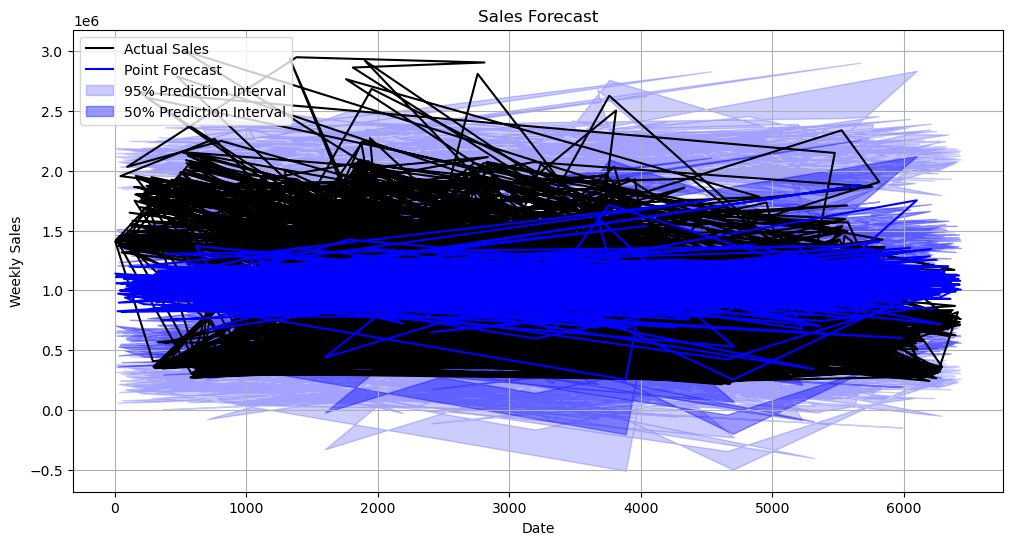

            Date      Actual      Forecast    PI_50_lower   PI_50_upper  \
5207  25-03-2011   522105.93  1.045891e+06  614816.480777  1.399217e+06   
2776  25-03-2011  1824711.21  1.099372e+06  663356.438319  1.467027e+06   
5779  25-03-2011  1140578.16  1.237542e+06  778079.412656  1.577711e+06   
1489  25-03-2011  1229777.24  1.160506e+06  720891.284984  1.547106e+06   
1632  25-03-2011   954107.32  1.020247e+06  555085.842158  1.396710e+06   

        PI_95_lower   PI_95_upper  
5207  284550.964428  2.114349e+06  
2776  342479.479264  2.144933e+06  
5779  483748.968104  2.298509e+06  
1489  393471.646655  2.192876e+06  
1632  267333.432326  2.090490e+06  

Plain-English explanation:

- The point forecast is our best estimate of future sales given the model.
- The 50% prediction interval means there is a 50% chance the true sales will fall within this range.
- The 95% prediction interval is wider, reflecting greater uncertainty, with 95% chance the true sales fall inside.
- Wider int

In [26]:
import pandas as pd
import numpy as np
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# Load dataset (adjust path)
df = pd.read_csv("Walmart.csv")

# Sort by date
df = df.sort_values('Date')

# Feature engineering: lagged sales + other predictors
df['Weekly_Sales_lag_7'] = df['Weekly_Sales'].shift(7)
df = df.dropna(subset=['Weekly_Sales_lag_7'])

features = ['Weekly_Sales_lag_7', 'Holiday_Flag', 'Temperature']
X = df[features]
y = df['Weekly_Sales']

# Split into train/test (last 20% as test)
split_idx = int(len(df)*0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# Fit Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=200, random_state=42)
gbr.fit(X_train, y_train)

# Predict on test set (point forecasts)
y_pred = gbr.predict(X_test)

# Calculate residuals on train set (for bootstrap)
train_pred = gbr.predict(X_train)
residuals = y_train - train_pred

# Residual bootstrap for prediction intervals
n_bootstrap = 1000
boot_preds = np.zeros((n_bootstrap, len(X_test)))

np.random.seed(42)
for i in range(n_bootstrap):
    # Sample residuals with replacement
    res_sample = np.random.choice(residuals, size=len(X_test), replace=True)
    boot_preds[i] = y_pred + res_sample

# Compute prediction intervals (50% and 95%)
pi_50_lower = np.percentile(boot_preds, 25, axis=0)
pi_50_upper = np.percentile(boot_preds, 75, axis=0)
pi_95_lower = np.percentile(boot_preds, 2.5, axis=0)
pi_95_upper = np.percentile(boot_preds, 97.5, axis=0)

# Plot forecasts and prediction intervals
plt.figure(figsize=(12,6))
plt.plot(y_test.index, y_test, label='Actual Sales', color='black')
plt.plot(y_test.index, y_pred, label='Point Forecast', color='blue')
plt.fill_between(y_test.index, pi_95_lower, pi_95_upper, color='blue', alpha=0.2, label='95% Prediction Interval')
plt.fill_between(y_test.index, pi_50_lower, pi_50_upper, color='blue', alpha=0.4, label='50% Prediction Interval')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.title('Sales Forecast')
plt.legend()
plt.grid(True)
plt.show()

# Numeric table of forecasts with intervals
forecast_df = pd.DataFrame({
    'Date': df['Date'].iloc[split_idx:],
    'Actual': y_test,
    'Forecast': y_pred,
    'PI_50_lower': pi_50_lower,
    'PI_50_upper': pi_50_upper,
    'PI_95_lower': pi_95_lower,
    'PI_95_upper': pi_95_upper
})
print(forecast_df.head())

print("""
Plain-English explanation:

- The point forecast is our best estimate of future sales given the model.
- The 50% prediction interval means there is a 50% chance the true sales will fall within this range.
- The 95% prediction interval is wider, reflecting greater uncertainty, with 95% chance the true sales fall inside.
- Wider intervals indicate higher uncertainty; narrow intervals indicate more confidence.
- Prediction intervals account for both model uncertainty and natural variability in sales.
- They help businesses plan for best- and worst-case scenarios, rather than relying on a single forecast.
""")
